In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout

from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.callbacks import Callback

## Mounting to Google Drive

### Uncomment if utilizing Google Colab

In [2]:
colab = False

In [3]:
path = os.getcwd()
print(path)
if colab:
    from google.colab import drive 
    drive.mount('/content/drive')
    os.chdir("./drive/My Drive/TreatmentSystems/Final_Dataset")
else:
    os.chdir(os.path.join(path, 'Final_Dataset'))

print(os.getcwd())

c:\Users\nwalr\OneDrive - Georgia Institute of Technology\VIP\TreatmentSystems
c:\Users\nwalr\OneDrive - Georgia Institute of Technology\VIP\TreatmentSystems\Final_Dataset


### Receiving Data and Completing Train-Test Split

In [4]:
data = pd.read_csv('concatenated_data.csv')
print(type(data))
print(data.head())

# is_sorted = data.equals(data.sort_values(by=['PatientID', 'time']).reset_index(drop=True))
# print("Data is sorted correctly:", is_sorted)
times = data.pop('time')

data.head()

numPatients = data['PatientID'].max()
print(numPatients)

<class 'pandas.core.frame.DataFrame'>
               time  PatientID  calories  heart_rate  steps  basal_rate  \
0  06-13-2018 18:40          1    6.3595   82.322835     34    0.091667   
1  06-13-2018 18:45          1    7.7280   83.740157      0    0.091667   
2  06-13-2018 18:50          1    4.7495   80.525180      0    0.091667   
3  06-13-2018 18:55          1    6.3595   89.129032     20    0.091667   
4  06-13-2018 19:00          1    5.1520   92.495652      0    0.075000   

   bolus_volume_delivered  glucose  
0                     0.0    332.0  
1                     0.0    326.0  
2                     0.0    330.0  
3                     0.0    324.0  
4                     0.0    306.0  
22


In [5]:
print((data['basal_rate'] >= 0).all() and (data['basal_rate'] <= 1).all())

True


In [6]:
print((data['bolus_volume_delivered'] >= 0).all() and (data['bolus_volume_delivered'] <= 1).all())

False


In [7]:
train_patients = list(range(1, 17))
print(len(train_patients))
print(train_patients)

test_patients = list(range(17, numPatients + 1))
print(len(test_patients))
print(test_patients)

train_data = data[data['PatientID'].isin(train_patients)]
test_data = data[data['PatientID'].isin(test_patients)]

print("\n Training Data:")
train_X, train_y = train_data.loc[:, data.columns != 'glucose'], train_data['glucose']
print(train_X.head())
print(train_y.head())

train_len = len(train_X)
N = len(data)
print(train_len, N)
train_percent = (train_len / N)

print("Percent of Data in Training = ", np.round(train_percent * 100, 2))
print("\n Testing Data:")
test_X, test_y = test_data.loc[:, data.columns != 'glucose'], test_data['glucose']
print(test_X.head())
print(test_y.head())

print("Percent of Data in Testing = ", np.round((1 - train_percent) * 100, 2))

16
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
6
[17, 18, 19, 20, 21, 22]

 Training Data:
   PatientID  calories  heart_rate  steps  basal_rate  bolus_volume_delivered
0          1    6.3595   82.322835     34    0.091667                     0.0
1          1    7.7280   83.740157      0    0.091667                     0.0
2          1    4.7495   80.525180      0    0.091667                     0.0
3          1    6.3595   89.129032     20    0.091667                     0.0
4          1    5.1520   92.495652      0    0.075000                     0.0
0    332.0
1    326.0
2    330.0
3    324.0
4    306.0
Name: glucose, dtype: float64
46080 63360
Percent of Data in Training =  72.73

 Testing Data:
       PatientID  calories  heart_rate  steps  basal_rate  \
46080         17   15.0429   96.371901      8       0.035   
46081         17    8.3164   91.395349      0       0.035   
46082         17    7.5826   85.991935      0       0.035   
46083         17    7.3380   82.434

### Scale the Features Before Training

#### Columns That Needed to Be Scaled:
- Calories
- Steps
- Heart Rate
- Glucose

Possibly Need to Scale the Basal Rate -> First Attempt will be without scaling the Basal

Note that Glucose Needs to be converted back to the original values before the scaling in order to interpret the results

In [8]:
print("Calories:")
print("Min = ", train_X['calories'].min())
print("Max = ", train_X['calories'].max())

print("Heart Rate:")
print("Min = ", train_X['heart_rate'].min())
print("Max = ", train_X['heart_rate'].max())

print("Steps:")
print("Min = ", train_X['steps'].min())
print("Max = ", train_X['steps'].max())

print("Basal Rate:")
print("Min = ", train_X['basal_rate'].min())
print("Max = ", train_X['basal_rate'].max())

Calories:
Min =  4.025000036
Max =  78.85771084
Heart Rate:
Min =  39.38406616
Max =  174.7142857
Steps:
Min =  0
Max =  658
Basal Rate:
Min =  0.0
Max =  0.25


In [9]:
scaler1_x = MinMaxScaler(feature_range=(-1, 1))
scaler1_y = MinMaxScaler(feature_range=(-1, 1))

In [10]:
column_names = data.columns
print(column_names[-3:-1])
print(column_names[:1])
print(column_names[1:data.shape[1] - 3])
standardize_features = list(column_names[1:data.shape[1] - 3]) # Features to standardize
passthrough_features = list(column_names[-3:-1]) # Keep these unchanged
print(standardize_features, passthrough_features)

# Define ColumnTransformer
scaler1_x = ColumnTransformer(
    transformers=[
        ('passthrough', 'passthrough', passthrough_features), 
        ('standardize', MinMaxScaler(), standardize_features)
    ]
)

train_X_scaled = scaler1_x.fit_transform(train_X)
test_X_scaled = scaler1_x.transform(test_X)

print(train_X_scaled[:5], type(train_X_scaled))
print(test_X_scaled[:5], type(test_X_scaled))

Index(['basal_rate', 'bolus_volume_delivered'], dtype='object')
Index(['PatientID'], dtype='object')
Index(['calories', 'heart_rate', 'steps'], dtype='object')
['calories', 'heart_rate', 'steps'] ['basal_rate', 'bolus_volume_delivered']
[[0.09166667 0.         0.03119625 0.31728884 0.05167173]
 [0.09166667 0.         0.04948371 0.32776191 0.        ]
 [0.09166667 0.         0.0096816  0.30400537 0.        ]
 [0.09166667 0.         0.03119625 0.3675821  0.03039514]
 [0.075      0.         0.01506026 0.39245917 0.        ]] <class 'numpy.ndarray'>
[[0.035      0.         0.14723374 0.42110206 0.01215805]
 [0.035      0.         0.05734658 0.38432867 0.        ]
 [0.035      0.         0.04754071 0.34440105 0.        ]
 [0.035      0.         0.04427208 0.31811343 0.        ]
 [0.035      0.         0.04754071 0.2914243  0.        ]] <class 'numpy.ndarray'>


In [11]:
print("Glucose")
print("Min = ", train_y.min())
print("Max = ", train_y.max())

Glucose
Min =  40.0
Max =  444.0


In [12]:
scaler1_y = MinMaxScaler()
train_y_scaled = scaler1_y.fit_transform(np.array(train_y).reshape(-1, 1))
test_y_scaled = scaler1_y.transform(np.array(test_y).reshape(-1, 1))

print(train_y_scaled[:5])
print(test_y_scaled[:5])

[[0.72277228]
 [0.70792079]
 [0.71782178]
 [0.7029703 ]
 [0.65841584]]
[[0.        ]
 [0.00330033]
 [0.00660066]
 [0.00990099]
 [0.02475248]]


In [18]:
sequence_length, batch_size = 60, 32
n_features = 5

train_gen = TimeseriesGenerator(train_X_scaled, train_y_scaled, length=sequence_length, batch_size = batch_size)
test_gen = TimeseriesGenerator(test_X_scaled, test_y_scaled, length=sequence_length, batch_size=batch_size)

In [21]:
print(type(train_gen))
print(type(test_gen))

print(len(train_gen))
print(train_gen[0])

x, y = train_gen[0]

print(x.shape)
print(y.shape)

<class 'keras.src.legacy.preprocessing.sequence.TimeseriesGenerator'>
<class 'keras.src.legacy.preprocessing.sequence.TimeseriesGenerator'>
1439
(array([[[0.09166667, 0.        , 0.03119625, 0.31728884, 0.05167173],
        [0.09166667, 0.        , 0.04948371, 0.32776191, 0.        ],
        [0.09166667, 0.        , 0.0096816 , 0.30400537, 0.        ],
        ...,
        [0.        , 0.        , 0.00430293, 0.38022501, 0.        ],
        [0.        , 0.        , 0.00107573, 0.34414753, 0.        ],
        [0.        , 0.        , 0.        , 0.29273531, 0.        ]],

       [[0.09166667, 0.        , 0.04948371, 0.32776191, 0.        ],
        [0.09166667, 0.        , 0.0096816 , 0.30400537, 0.        ],
        [0.09166667, 0.        , 0.03119625, 0.3675821 , 0.03039514],
        ...,
        [0.        , 0.        , 0.00107573, 0.34414753, 0.        ],
        [0.        , 0.        , 0.        , 0.29273531, 0.        ],
        [0.        , 0.        , 0.01828746, 0.362433  ,

In [22]:
model1 = Sequential()
model1.add(LSTM(100, activation='relu', input_shape=(sequence_length, n_features)))
model1.add(Dense(1))

adam_opt = keras.optimizers.Adam(learning_rate=0.001)
model1.compile(loss='mse', optimizer = adam_opt)

# fit model
history = model1.fit(train_gen, validation_data=test_gen, epochs = 20, verbose=2)

preds = model1.predict(test_gen)
y_true = test_y_scaled[sequence_length:]

y_pred_original = scaler1_y.inverse_transform(preds)
y_true_original = scaler1_y.inverse_transform(y_true.reshape(-1, 1))

Epoch 1/20
1439/1439 - 153s - 106ms/step - loss: 0.0315 - val_loss: 0.0244
Epoch 2/20
1439/1439 - 101s - 70ms/step - loss: 0.0295 - val_loss: 0.0237
Epoch 3/20
1439/1439 - 50s - 35ms/step - loss: 0.0295 - val_loss: 0.0178
Epoch 4/20
1439/1439 - 46s - 32ms/step - loss: 0.0291 - val_loss: 0.0289
Epoch 5/20
1439/1439 - 36s - 25ms/step - loss: 0.0289 - val_loss: 0.0258
Epoch 6/20
1439/1439 - 40s - 28ms/step - loss: 8.0323 - val_loss: 0.0253
Epoch 7/20
1439/1439 - 36s - 25ms/step - loss: 0.7634 - val_loss: 0.0221
Epoch 8/20
1439/1439 - 51s - 35ms/step - loss: 0.0290 - val_loss: 0.0287
Epoch 9/20
1439/1439 - 45s - 31ms/step - loss: 0.0288 - val_loss: 0.0217
Epoch 10/20
1439/1439 - 65s - 45ms/step - loss: 0.0286 - val_loss: 0.0203
Epoch 11/20
1439/1439 - 77s - 53ms/step - loss: 0.0285 - val_loss: 0.0343
Epoch 12/20
1439/1439 - 36s - 25ms/step - loss: 0.0283 - val_loss: 0.0219
Epoch 13/20
1439/1439 - 36s - 25ms/step - loss: 0.0280 - val_loss: 0.0247
Epoch 14/20
1439/1439 - 36s - 25ms/step - lo

In [ ]:
print(y_pred_original)
print(y_true_original)

print("R2 Score = ", r2_score(y_true_original, y_pred_original))

[[143.15721]
 [142.80533]
 [142.48038]
 ...
 [164.76285]
 [164.90433]
 [164.16618]]
[[144.        ]
 [149.3333333 ]
 [154.6666667 ]
 ...
 [ 95.66666667]
 [ 98.33333333]
 [101.        ]]
R2_score =  -0.17568844448666932


### Creation of Plots for Visualizations

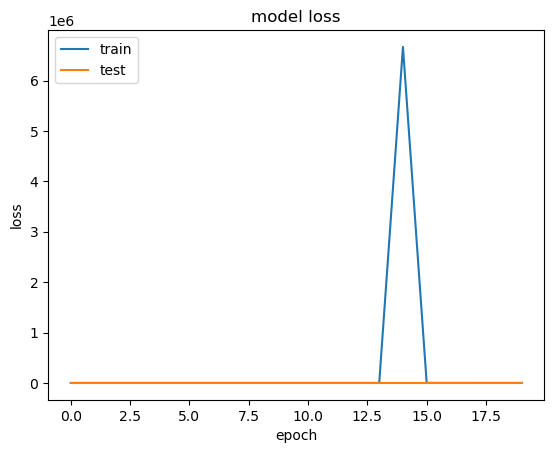

In [23]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

#### Model 2: Deep LSTM with Dropout

In [ ]:
model2 = Sequential()
#Layer 1
model2.add(LSTM(100, activation='relu', return_sequences= True, input_shape=(sequence_length, n_features)))
model2.add(Dropout(0.2))

#Layer 2
model2.add(LSTM(85, activation = 'relu', return_sequences=True))
model2.add(Dropout(0.2))

#Layer 2
model2.add(LSTM(60, activation = 'relu', return_sequences=True))
model2.add(Dropout(0.2))

#Layer 2
model2.add(LSTM(45, activation = 'relu', return_sequences=True))
model2.add(Dropout(0.2))

#Layer 2
model2.add(LSTM(40, activation = 'relu', return_sequences=True))
model2.add(Dropout(0.2))

model2.add(Dense(1))

adam_opt = keras.optimizers.Adam(learning_rate=0.001)
model2.compile(loss='mse', optimizer = adam_opt)

# fit model
history2 = model2.fit(train_gen, validation_data=test_gen, epochs = 20, verbose=2, shuffle = False)

preds = model2.predict(test_gen)
y_true = test_y_scaled[sequence_length:]

y_pred_original = scaler1_y.inverse_transform(preds)
y_true_original = scaler1_y.inverse_transform(y_true.reshape(-1, 1))

In [ ]:
print(y_pred_original)
print(y_true_original)

print("R2 Score = ", r2_score(y_true_original, y_pred_original))

In [ ]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

#### Scalar Modifications in Min-Max Scalar